# Análisis de Rendimiento y Convergencia HPC
Este notebook procesa los resultados obtenidos en las simulaciones de Monte Carlo para calcular el Speedup, la Eficiencia y el Error Absoluto.

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

### 1. Carga de datos y cálculo de Medianas (Tiempos y Estimaciones)

In [19]:
# Cargamos los CSVs generados por los scripts de Bash
df_integral = pd.read_csv('integral_resultados.csv')
df_area = pd.read_csv('area_resultados.csv')

# Agrupamos por Tamaño (N) y número de procesos, calculando la mediana del tiempo y del valor estimado
med_integral = df_integral.groupby(['N', 'procesos'])[['tiempo_segundos', 'valor_estimado']].median().reset_index()
med_area = df_area.groupby(['N', 'procesos'])[['tiempo_segundos', 'valor_estimado']].median().reset_index()

med_integral['Método'] = 'Integral 1D'
med_area['Método'] = 'Área 2D'

df_resultados = pd.concat([med_integral, med_area])
display(df_resultados.head())

,N,procesos,tiempo_segundos,valor_estimado,Método
0,10000,1,0.000095,0.332604,Integral 1D
1,10000,2,0.000055,0.332190,Integral 1D
2,10000,4,0.000059,0.333489,Integral 1D
3,10000,6,0.000055,0.332198,Integral 1D
4,1000000,1,0.008224,0.333204,Integral 1D


### 2. Cálculo del Speedup, Eficiencia y Error Absoluto
Como Monte Carlo converge con el aumento de N, usaremos los valores teóricos esperados para analizar el error.

In [20]:
def calcular_metricas(df):
    # Speedup y Eficiencia
    df_t1 = df[df['procesos'] == 1].set_index(['Método', 'N'])['tiempo_segundos']
    df['T1'] = df.set_index(['Método', 'N']).index.map(df_t1)
    df['Speedup'] = df['T1'] / df['tiempo_segundos']
    df['Eficiencia'] = df['Speedup'] / df['procesos']
    
    # Convergencia (Error Absoluto)
    # Valor analítico Integral 1D: 1/3 (0.3333...)
    # Valor analítico Área 2D (Círculo de r=1): Pi (3.1415...)
    def obtener_error(row):
        if row['Método'] == 'Integral 1D':
            return abs(row['valor_estimado'] - (1.0 / 3.0))
        else:
            return abs(row['valor_estimado'] - np.pi)
            
    df['Error Absoluto'] = df.apply(obtener_error, axis=1)
    return df

df_resultados = calcular_metricas(df_resultados)
display(df_resultados.head())

,N,procesos,tiempo_segundos,valor_estimado,Método,T1,Speedup,Eficiencia,Error Absoluto
0,10000,1,0.000095,0.332604,Integral 1D,0.000095,1.000000,1.000000,0.000729
1,10000,2,0.000055,0.332190,Integral 1D,0.000095,1.727273,0.863636,0.001143
2,10000,4,0.000059,0.333489,Integral 1D,0.000095,1.610169,0.402542,0.000156
3,10000,6,0.000055,0.332198,Integral 1D,0.000095,1.727273,0.287879,0.001135
4,1000000,1,0.008224,0.333204,Integral 1D,0.008224,1.000000,1.000000,0.000129


### 3. Gráfico de Convergencia: Error Absoluto vs. Simulaciones (N)

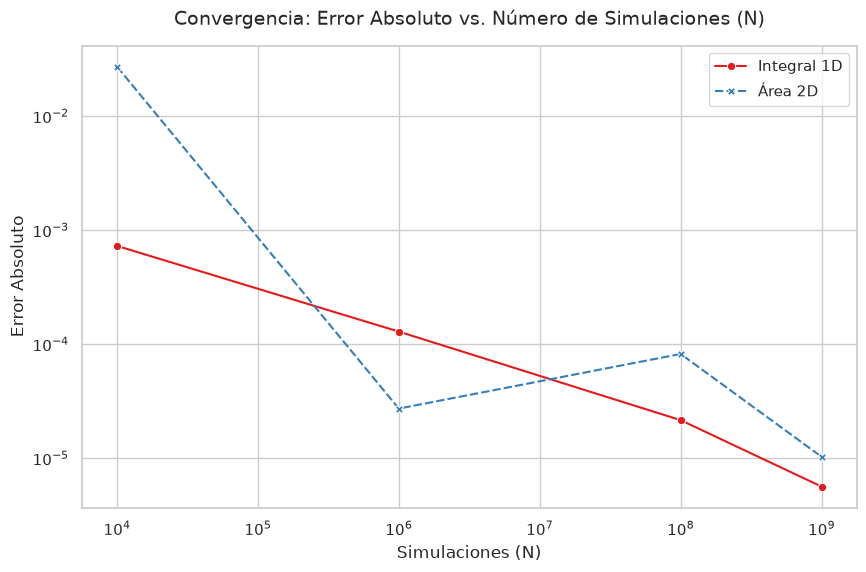

In [21]:
plt.figure(figsize=(10, 6))

# Filtramos para mostrar la convergencia (usamos la corrida secuencial p=1 como referencia estadística)
df_convergencia = df_resultados[df_resultados['procesos'] == 1]

sns.lineplot(data=df_convergencia, x='N', y='Error Absoluto', hue='Método', markers=True, style='Método', palette='Set1')

plt.title('Convergencia: Error Absoluto vs. Número de Simulaciones (N)', fontsize=14, pad=15)
plt.xlabel('Simulaciones (N)', fontsize=12)
plt.ylabel('Error Absoluto', fontsize=12)
plt.xscale('log')
plt.yscale('log') # Escala log-log para observar la caída característica de Monte Carlo
plt.legend()
plt.show()

### 4. Gráfico de Speedup

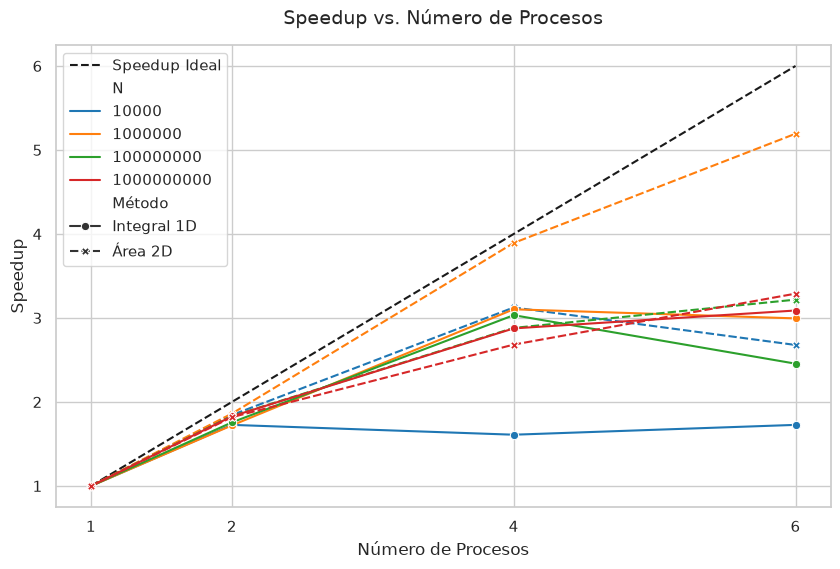

In [22]:
plt.figure(figsize=(10, 6))

max_p = df_resultados['procesos'].max()
plt.plot([1, max_p], [1, max_p], 'k--', label='Speedup Ideal')

sns.lineplot(data=df_resultados, x='procesos', y='Speedup', hue='N', style='Método', markers=True, palette='tab10')

plt.title('Speedup vs. Número de Procesos', fontsize=14, pad=15)
plt.xlabel('Número de Procesos', fontsize=12)
plt.ylabel('Speedup', fontsize=12)
plt.xticks(df_resultados['procesos'].unique())
plt.legend()
plt.show()

### 5. Gráfico de Eficiencia

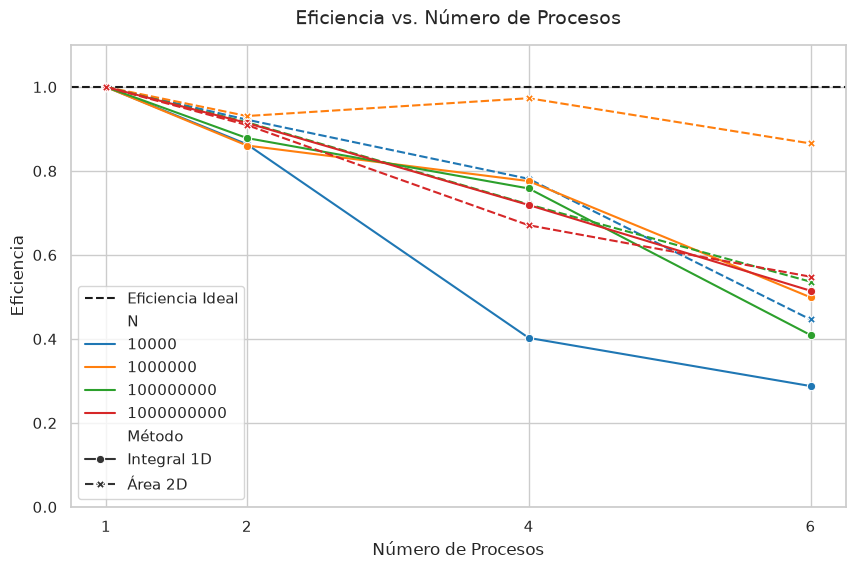

In [23]:
plt.figure(figsize=(10, 6))
plt.axhline(y=1.0, color='k', linestyle='--', label='Eficiencia Ideal')

sns.lineplot(data=df_resultados, x='procesos', y='Eficiencia', hue='N', style='Método', markers=True, palette='tab10')

plt.title('Eficiencia vs. Número de Procesos', fontsize=14, pad=15)
plt.xlabel('Número de Procesos', fontsize=12)
plt.ylabel('Eficiencia', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(df_resultados['procesos'].unique())
plt.legend(loc='lower left')
plt.show()